_ExplainDB — Copyright (C) 2026 Prof. Dr. Jens Dittrich, Saarland University._  
_Licensed under the GNU Affero General Public License v3 (AGPL-3.0). See the `LICENSE` file._

# Speeding Up Search on Sorted Data with Recursive Model Indexes

How can we efficiently and repeatedly search a sorted list of numeric values for a target value? Since the sorted list may contain duplicates, we focus on lower bounds searches in this notebook, i.e., we are looking for the first element in the sorted list that is not less than the target value.

## Preparation: Creating Synthetic Data

We generate a synthetic dataset based on a simple polynomial function with added noise. This should produce an interesting distribution, where the density of the key space gradually decreases.

In [ ]:
import random
from typing import List, Callable

# Set seed to ensure reproducibility
random.seed(0)

# Define dataset size and polynomial function.
# The dataset size drives the whole notebook: it sets the cost of building and
# sorting the data, the number of benchmark queries (20% of it), and every
# per-element prediction loop. At 1,000,000 the notebook runs ~23s, which makes
# it the slowest in CI. We use 100,000 to keep CI fast (~5s) while the
# RMI-vs-binary-search comparison and the error plots stay representative.
# For the lecture, uncomment the 1_000_000 line for the full-scale numbers.
dataset_size: int = 100_000
# dataset_size: int = 1_000_000
poly_fn: Callable[[int], int] = lambda x: int(1 / 1000 * x**2)

# Generate dataset based on polynomial function and add noise
dataset: List[int] = []
for i in range(dataset_size):
    value: int = poly_fn(i)
    noise: int = random.randint(int(-dataset_size * 0.001), int(dataset_size * 0.001))
    dataset.append(value + noise)

# Sort dataset
dataset = sorted(dataset)

Let's visualize the dataset as histogram. We can see that the density of keys decreases towards the upper end of the domain.

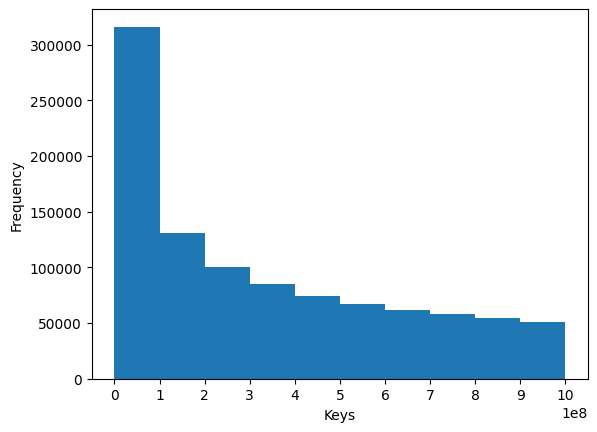

In [2]:
import matplotlib.pyplot as plt

# Visualize the data distribution as histogram
fig, ax = plt.subplots()
counts, bins, patches = ax.hist(dataset, bins=10)
ax.set_xlabel("Keys")
ax.set_ylabel("Frequency")
ax.set_xticks([abs(b) for b in bins])
plt.show()

## Algorithm 1: Binary Search

Binary search is the de facto standard approach for searching sorted data. In this variant, we can optionally provide a start point for the first comparison along with lower and upper bounds to further restrict the search space. We will later make use of these three parameters.

In [3]:
from typing import Optional


def lower_bound_binary_search(
    sorted_list: List[int],
    value: int,
    start: Optional[int] = None,
    lo: Optional[int] = None,
    hi: Optional[int] = None,
) -> int:
    """
    Performs a binary search to find the index of the first element in @p sorted_list that is not less than @p value. Optionally, @p lo, @p hi, and @p start may be provided to restrict the search space and define a starting point for the search.

    :param sorted_list: The sorted list of integers to search.
    :param value: The target value to search for.
    :param start: The optional index to start searching from.
    :param lo: The optional lower bound (inclusive) of the search space. Defaults to the start of the list.
    :param hi: The optional upper bound (exclusive) of the search space. Defaults to the end of the list.
    :return: The index of the first element in the list that is not less than the value, or len(sorted_list) if no such element exists.

    :note: Restricting the search range with @p lo and @p hi may lead to incorrect results if the target value lies outside this range.
    """
    # Initialize bounds of the search space.
    lo = lo or 0
    hi = hi or len(sorted_list)
    assert lo <= hi, "Bounds must be valid."
    assert lo >= 0, "Lower bound must not be negative."
    assert hi <= len(sorted_list), "Upper bound must not exceed the length of the list."

    # Handle start parameter if provided.
    if start is not None:
        assert lo <= start < hi, "Start must be within bounds."
        if sorted_list[start] < value:
            # Start element is less than value, search right half.
            lo = start + 1
        else:
            # Start element is not less than value, search left half.
            hi = start

    # Continue searching while the lower bound is less than the upper bound.
    while lo < hi:
        # Calculate the middle index of the current search space
        mid: int = lo + (hi - lo) // 2
        if sorted_list[mid] < value:
            # Middle element is less than value, search right half.
            lo = mid + 1
        else:
            # Middle element is not less than value, search left half.
            hi = mid
    # Return index of first element that is not less than key.
    return lo


# Test binary search
val: int = 1337
idx: int = lower_bound_binary_search(dataset, val)
print(f"Binary Search: Value {val} was located at index {idx}.")

Binary Search: Value 1337 was located at index 1135.


## Algorithm 2: Recursive Model Index Without Bounds

If the same data is searched repeatedly, it might pay off to create an index on the data. Here, we want to introduce the Recursive Model Index (RMI) which pioneered the research field of **learned indexes**.

### Core Idea

The RMI uses machine learning to model the relationship between keys and their index in the sorted list. At its most basic, an RMI can be implemented using a single model to predict this mapping. As the model's prediction may be imprecise, the RMI employs a local search around the predicted index to determine the actual index, e.g., linear search or exponential search starting from the predicted position.

Let us first define a simple linear spline model that serves as foundation of our RMI implementation. This model simply fits a straight line through the points (first key, 0) and (last key, N - 1), where N is the size of the dataset.

In [4]:
def is_sorted(lst: List[int]) -> bool:
    """
    Checks if @p lst is sorted in ascending order.

    :param lst: List of integers.
    :return: True if @p lst is sorted in ascending order.
    """
    return all(lst[i] <= lst[i + 1] for i in range(len(lst) - 1))


class LinearSplineModel:
    """
    A simple linear spline model that fits a straight line between the first and last points of a given dataset.

    Attributes:
        slope_ (float): The slope of the fitted line.
        intercept_ (float): The intercept of the fitted line.
    """

    def __init__(self, X: List[int], Y: List[int]) -> None:
        """
        Initializes the linear spline model with input @p X and target @p Y.

        :param X: List of input values.
        :param Y: List of target values.
        """
        assert is_sorted(X), "Inputs must be sorted in ascending order."
        assert len(X) == len(Y), "Inputs and targets must have same length."
        if len(X) == 0:
            self.slope_: float = 0.0
            self.intercept_: float = 0.0
        elif len(X) == 1:
            self.slope_: float = 0.0
            self.intercept_: float = Y[0]
        else:
            self.slope_: float = (Y[-1] - Y[0]) / (X[-1] - X[0])
            self.intercept_: float = Y[0] - (self.slope_ * X[0])

    def predict(self, x: int) -> float:
        """
        Predicts target value for a given input value @p x by applying the linear spline model.

        :param x: Input value.
        :return: Predicted value for input @p x.
        """
        return self.slope_ * x + self.intercept_

Next, let us define the exponential search. Like the binary search before, this search determines the lower bound and can be provided with optional starting point, lower bound, and upper bound for the search.

In [5]:
def lower_bound_exponential_search(
    sorted_list: List[int],
    value: int,
    start: Optional[int] = None,
    lo: Optional[int] = None,
    hi: Optional[int] = None,
) -> int:
    """
    Performs an exponential search to find the index of the first element in @p sorted_list that is not less than @p value. Optionally, @p lo, @p hi, and @p start may be provided to restrict the search space and define a starting point for the search.

    :param sorted_list: The sorted list of integers to search.
    :param value: The target value to search for.
    :param start: The optional index to start searching from.
    :param lo: The optional lower bound (inclusive) of the search space. Defaults to the start of the list.
    :param hi: The optional upper bound (exclusive) of the search space. Defaults to the end of the list.
    :return: The index of the first element in the list that is not less than the value, or len(sorted_list) if no such element exists.

    :note: Restricting the search range with @p lo and @p hi may lead to incorrect results if the target value lies outside this range.
    """
    # Initialize bounds of the search space.
    lo = lo or 0
    hi = hi or len(sorted_list)
    assert lo <= hi, "Bounds must be valid."
    assert lo >= 0, "Lower bound must not be negative."
    assert hi <= len(sorted_list), "Upper bound must not exceed the length of the list."
    start = start or lo
    assert lo <= start < hi, "Start must be within bounds."

    # Initialize interval size and store start of current interval
    bound: int = 1
    prev: int = start

    if sorted_list[start] < value:
        # Start element is less than value, search to the right side.
        curr = min(prev + bound, hi)
        while curr < hi and sorted_list[curr] < value:
            bound *= 2
            prev = curr
            curr: int = min(prev + bound, hi)
        # Interval containing value determined, search interval using binary search.
        return lower_bound_binary_search(
            sorted_list, value, lo=prev, hi=min(curr + 1, len(sorted_list))
        )
    # Start element is not less than value, search to the left side.
    curr = max(prev - bound, lo)
    while curr > lo and sorted_list[curr] >= value:
        bound *= 2
        prev = curr
        curr: int = max(prev - bound, lo)
    # Interval containing value determined, search interval using binary search.
    return lower_bound_binary_search(sorted_list, value, lo=curr, hi=prev)


# Test exponential search
idx = lower_bound_exponential_search(dataset, val)
print(f"Exponential Search: Value {val} was located at index {idx}.")

Exponential Search: Value 1337 was located at index 1135.



### Algorithm 2a: Single-Layer Recursive Model Index

We are now ready to define a simple single-layer RMI consisting of a single linear model. When searching for a particular key, the RMI first predicts the position of the key, clamps it to the interval [0, N), and then utilizes exponential search to determine the actual index.


In [6]:
class SingleLayerRMI:
    """
    A Single-Layer Recursive Model Index for efficient searching in a sorted list.

    Attributes:
        N (int): The number of elements in the sorted list.
        model (LinearSplineModel): A linear spline model trained on the sorted list to predict positions for input values.
    """

    def __init__(self, sorted_list: List[int]) -> None:
        """
        Initializes the RMI and its underlying model with a sorted list @p sorted_list of integers in ascending order.

        :param sorted_list: The sorted list of integers.
        """
        assert len(sorted_list) > 0, "Inputs must not be empty."
        assert is_sorted(sorted_list), "Inputs must be sorted in ascending order."

        self.N = len(sorted_list)  # Number of elements in the sorted list

        # Train linear spline model on map input values to their approximate index.
        self.model = LinearSplineModel(sorted_list, list(range(self.N)))

    def _predict(self, value: int) -> int:
        """
        Predicts the approximate index for a given input @p value.

        :param value: The value for which to predict the index.
        :return: Approximate index of the input value, clamped to the range [0, N] of valid indexes.
        """
        return max(0, min(self.N - 1, int(self.model.predict(value))))

    def lower_bound_search(self, sorted_list: List[int], value: int) -> int:
        """
        Performs a search to find the index of the first element in @p sorted_list that is not less than @p value. The function first uses the linear spline model to predict an index for the input value and then performs an exponential search to determine the actual index.

        :param sorted_list: The sorted list of integers to search.
        :param value: The target value to search for.
        :return: The index of the first element in the list that is not less than the value, or len(sorted_list) if no such element exists found.

        :note: The function assumes that the RMI was built on @p sorted_list.
        """
        # Predict index using model.
        pred: int = self._predict(value)
        # Correct errors by performing search.
        return lower_bound_exponential_search(sorted_list, value, start=pred)


# Test single-layer RMI
single_layer_rmi: SingleLayerRMI = SingleLayerRMI(dataset)
idx = single_layer_rmi.lower_bound_search(dataset, val)
print(f"Single-Layer RMI: Value {val} was located at index {idx}.")

Single-Layer RMI: Value 1337 was located at index 1135.


Let us next compare the performance of binary search and this simple single-layer RMI. For this purpose, we first draw a subset of keys from the original dataset to use for our benchmark.

In [7]:
# Re-set seed to ensure reproducibility
random.seed(0)

# Draw a subset of the dataset for benchmarking (20%)
num_benchmark_queries: int = int(0.2 * len(dataset))
queries: List[int] = [random.choice(dataset) for _ in range(num_benchmark_queries)]

Next, we define a function that executes all queries on a given algorithm and measures the average time per query. Additionally, the function generates a checksum to make sure the algorithms actually come up with the same results.

In [8]:
import time
from tqdm import tqdm
from typing import Callable


def benchmark(
    competitor: str,
    competitor_fn: Callable[[List[int], int], int],
    sorted_list: List[int],
    queries: List[int],
) -> int:
    """
    Benchmarks the performance of @p competitor by executing @p queries on @p competitor_fn. Reports the average time per query in nanoseconds and a checksum.

    :param competitor: Name of the competitor.
    :param competitor_fn: Function to execute a single search using competitor.
    :param sorted_list: The sorted list of integers.
    :param queries: List of queries to execute.
    """
    checksum: int = 0
    start: float = time.time()
    for query in tqdm(
        queries, desc=competitor, bar_format="Benchmarking {l_bar}{bar}|"
    ):
        checksum += competitor_fn(sorted_list, query)
    stop: float = time.time()
    avg_search_time_in_ns: int = int((stop - start) * 1_000_000_000 / len(queries))
    print(f"{competitor}: {avg_search_time_in_ns}ns (Checksum: {checksum}).")
    return avg_search_time_in_ns

We can now compare the performance of binary search and the single-layer RMI.

In [9]:
# Compare performance of binary search and single-layer RMI
bin_time: int = benchmark("Binary Search", lower_bound_binary_search, dataset, queries)
rmi_time: int = benchmark(
    "Single-Layer RMI", single_layer_rmi.lower_bound_search, dataset, queries
)

print(
    f"Binary search outperforms the single-layer RMI by a factor of {round(rmi_time/bin_time, 2)}x."
)

Benchmarking Binary Search: 100%|██████████|


Binary Search: 1768ns (Checksum: 99877252410).


Benchmarking Single-Layer RMI: 100%|██████████|

Single-Layer RMI: 4833ns (Checksum: 99877252410).
Binary search outperforms the single-layer RMI by a factor of 2.73x.


Unfortunately, the RMI is significantly slower than binary search. This is due to the fact that the predictions of the RMI are too inaccurate. To see this, let us compare the target function of the RMI that maps keys to their respective index with the approximation of that function using the single-layer RMI.

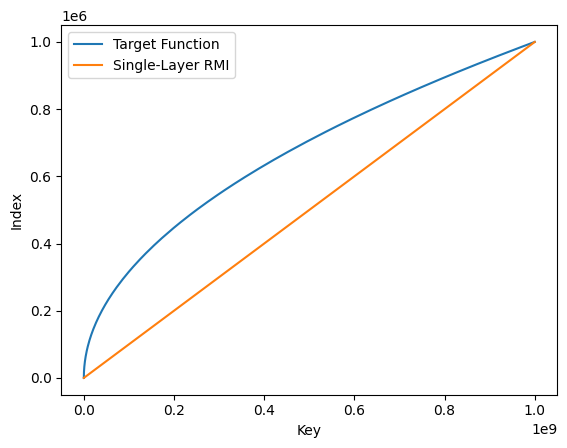

The RMI achieves a mean absolute error of 166666 and a median absolute error of 187500.


In [10]:
# Predict indexes for every element in dataset.
pred_single_layer_rmi: List[int] = [single_layer_rmi._predict(elem) for elem in dataset]

# Visually compare predictions and actual indexes.
fig, ax = plt.subplots()
ax.plot(dataset[::100], list(range(len(dataset)))[::100], label="Target Function")
ax.plot(dataset[::100], pred_single_layer_rmi[::100], label="Single-Layer RMI")
ax.set_xlabel("Key")
ax.set_ylabel("Index")
ax.legend()
plt.show()

import statistics

# Compute error metrics.
errors: List[float] = [
    abs(a - b) for a, b in zip(pred_single_layer_rmi, list(range(len(dataset))))
]
print(
    f"The RMI achieves a mean absolute error of {round(statistics.mean(errors))} and a median absolute error of {round(statistics.median(errors))}."
)

It becomes evident that the RMI must achieve more precise prediction to achieve better lookup performance.

### Algorithm 2b: Multi-Layer Recursive Model Index

To obtain more precise predictions, RMIs usually consist of two (or more) layers of models, where the models of each layer collectively approximate the target function. The first layer always consists of a single root model, while subsequent layers consist of multiple models. The idea is that each model has to cover a smaller range of keys, enabling more accurate predictions.

When performing a lookup, we first use the root model to predict the key's index, use this prediction to determine the responsible next-layer model and continue until obtaining the prediction of the responsible last-layer model. Based on this prediction, we again perform exponential search to determine the actual index.

Training of a multi-layer RMI is an iterative process, where the layers are trained top-down starting with the root model. Once a model is trained, we use the model's predictions of the keys it was trained on to assign the keys to models in the next layer and proceed with the next model in the current layer. Once a layer is fully trained, we move to the next layer. This process is continued until all models in all layers are trained. The idea is that we distribute the keys more evenly over next-layer models, ideally achieving an equi-depth partitioning in the last layer where each model has to cover the exact same amount of keys.  A nice property of this training algorithm is that if we query keys that are actually in the dataset, our lookup will only consider models that were actually trained on that key.

In [11]:
class MultiLayerRMI:
    """
    A Multi-Layer Recursive Model Index for efficient searching in a sorted list.

    Attributes:
        N (int): The number of elements in the sorted list.
        models (List[List[LinearSplineModel]]): A list of lists containing linear spline models trained on the sorted list to predict positions for input values. Each inner list represents one layer of the RMI.
    """

    def __init__(self, sorted_list: List[int], layer_sizes: List[int]) -> None:
        """
        Initializes the RMI and its underlying models with a sorted list @p sorted_list of integers in ascending order.

        :param sorted_list: The sorted list of integers.
        :param layer_sizes: The list of layer sizes.
        """
        assert len(sorted_list) > 0, "Inputs must not be empty."
        assert is_sorted(sorted_list), "Inputs must be sorted in ascending order."
        assert len(layer_sizes) > 0, "RMI must have at least one layer."
        assert layer_sizes[0] == 1, "First layer must consist of one model."

        self.N = len(sorted_list)

        # Initialize list with index for each value in sorted list.
        indexes: List[int] = list(range(len(sorted_list)))

        # Initialize temporary lists assigning (key, index) pairs to models. First dimension is layer, second dimension is model.
        model_keys: List[List[List[int]]] = [
            [[] for _ in range(layer_size)] for layer_size in layer_sizes
        ]
        model_indexes: List[List[List[int]]] = [
            [[] for _ in range(layer_size)] for layer_size in layer_sizes
        ]

        # Initially assign all (key, index) pairs so the root model (layer:0, model: 0)
        model_keys[0][0] = sorted_list
        model_indexes[0][0] = indexes

        # Initialize list of models. First dimension is layer, second dimension is model.
        self.models: List[List[LinearSplineModel]] = []

        # Train models layer by layer
        for layer, layer_size in enumerate(layer_sizes):
            # Initialize empty layer of models
            self.models.append([])

            for model in range(layer_size):
                # Train models in layer on assigned (key, index) pairs.
                m: LinearSplineModel = LinearSplineModel(
                    model_keys[layer][model], model_indexes[layer][model]
                )
                self.models[layer].append(m)

                if layer < len(layer_sizes) - 1:
                    # If we are not in the last layer, assign keys to next-layer models
                    for key, idx in zip(
                        model_keys[layer][model], model_indexes[layer][model]
                    ):
                        # Predict index for key and scale to size of next layer
                        pred: int = max(
                            0,
                            min(
                                self.N - 1, int(self.models[layer][model].predict(key))
                            ),
                        )
                        next_model: int = int(pred / self.N * layer_sizes[layer + 1])
                        # Assign to next-layer model
                        model_keys[layer + 1][next_model].append(key)
                        model_indexes[layer + 1][next_model].append(idx)

    def _get_last_layer_model(self, value: int) -> int:
        """
        Computes the index of the last layer model responsible for predicting the index of a given input @p value.

        :param value: The input value for which to determine the last layer model.
        :return: The index of the last layer model.
        """
        model: int = 0
        layer: int = 0
        # Continue while the last layer is not reached.
        while layer < len(self.models) - 1:
            # Predict position using a model in the current layer and scale it to the number next-layer models.
            pred: int = max(
                0, min(self.N - 1, int(self.models[layer][model].predict(value)))
            )
            model: int = int(pred / self.N * len(self.models[layer + 1]))
            layer += 1
        return model

    def _predict(self, value: int) -> int:
        """
        Predicts the approximate index for a given input @p value.

        :param value: The value for which to predict the index.
        :return: Approximate index of the input value, clamped to the range [0, N] of valid indexes.
        """
        # Determine responsible last-layer model.
        last_layer_model: int = self._get_last_layer_model(value)
        # Predict index using last-layer model and clamp
        pred: int = int(self.models[-1][last_layer_model].predict(value))
        return max(0, min(self.N - 1, pred))

    def lower_bound_search(self, sorted_list: List[int], value: int) -> int:
        """
        Performs a search to find the index of the first element in @p sorted_list that is not less than @p value. The function first uses the linear spline model to predict an index for the input value and then performs an exponential search to determine the actual index.

        :param sorted_list: The sorted list of integers to search.
        :param value: The target value to search for.
        :return: The index of the first element in the list that is not less than the value, or len(sorted_list) if no such element exists found.

        :note: The function assumes that the RMI was built on @p sorted_list.
        """
        # Predict index using model.
        pred: int = self._predict(value)
        # Correct errors by performing search.
        return lower_bound_exponential_search(sorted_list, value, start=pred)


# Test two-layer RMI
two_layer_rmi: MultiLayerRMI = MultiLayerRMI(
    dataset, [1, 1000]
)  # This model uses 1000 models in the second layer
idx = two_layer_rmi.lower_bound_search(dataset, val)
print(f"Two-Layer RMI: Value {val} was located at index {idx}.")

Two-Layer RMI: Value 1337 was located at index 1135.


Note that we used 1000 models in the second layer of the two-layer RMI above.

Let us now consider the two-layer RMI in our performance comparison.

In [12]:
# Compare performance of binary search, single-layer RMI, and two-layer RMI
bin_time = benchmark("Binary Search", lower_bound_binary_search, dataset, queries)
benchmark("Single-Layer RMI", single_layer_rmi.lower_bound_search, dataset, queries)
rmi_time = benchmark(
    "Two-Layer RMI", two_layer_rmi.lower_bound_search, dataset, queries
)

print(
    f"The two-layer RMI outperforms binary search by a factor of {round(bin_time / rmi_time, 2)}x."
)

Benchmarking Binary Search: 100%|██████████|


Binary Search: 1447ns (Checksum: 99877252410).


Benchmarking Single-Layer RMI: 100%|██████████|


Single-Layer RMI: 4343ns (Checksum: 99877252410).


Benchmarking Two-Layer RMI: 100%|██████████|

Two-Layer RMI: 1332ns (Checksum: 99877252410).
The two-layer RMI outperforms binary search by a factor of 1.09x.


This already suffices to slightly outperform binary search (on this machine).

Let us again consider the predictive accuracy of this RMI.

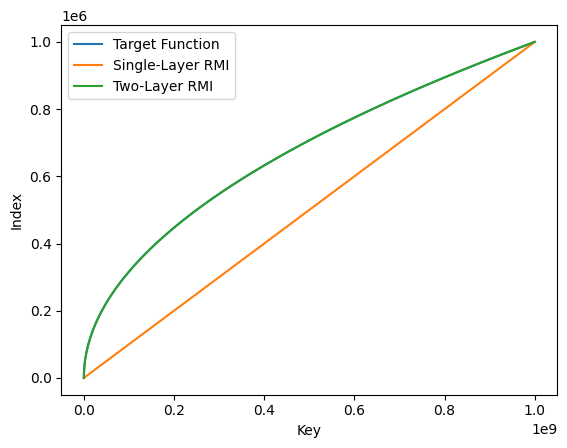

The two-layer RMI achieves a mean absolute error of 176 and a median absolute error of 1.


In [13]:
# Predict indexes for every element in dataset
pred_two_layer_rmi: List[int] = [two_layer_rmi._predict(elem) for elem in dataset]

# Visually compare predictions and actual indexes
fig, ax = plt.subplots()
ax.plot(dataset[::100], list(range(len(dataset)))[::100], label="Target Function")
ax.plot(dataset[::100], pred_single_layer_rmi[::100], label="Single-Layer RMI")
ax.plot(dataset[::100], pred_two_layer_rmi[::100], label="Two-Layer RMI")
ax.set_xlabel("Key")
ax.set_ylabel("Index")
ax.legend()
plt.show()

# Compute error metrics.
errors = [abs(a - b) for a, b in zip(pred_two_layer_rmi, list(range(len(dataset))))]
print(
    f"The two-layer RMI achieves a mean absolute error of {round(statistics.mean(errors))} and a median absolute error of {round(statistics.median(errors))}."
)

This predictive accuracy of the two-layer RMI improves significantly over the single-layer RMI. In the median case, the prediction is off by a single position but can we do even better?

## Algorithm 3: Recursive Model Index With Bounds

The RMIs above had to use exponential search to determine the actual position of a given key. To improve efficiency, the RMI can store the maximum absolute error _err_, observed during training. This allows it to limit the search range to [_pred_ - _err_, _pred_ + _err_], where _pred_ is the model's predicted position. A binary search can then be applied within this range to quickly find the correct index of the key.

In our implementation below, we store the maximum absolute error for each last-layer model individually. To do so, we extend the training process by recording these maximum absolute errors. We provide a new method that not only predicts the index of a given key but also provides lower and upper bounds for searching. This method is then used during a lookup to directly employ binary search instead of exponential search.

In [14]:
from typing import Tuple


class MultiLayerRMIWithBounds(MultiLayerRMI):
    """
    An extension of Multi-Layer Recursive Model Indexes that uses error bounds to limit the search space for correcting imprecise prediction.

    Attributes:
        errors (List[int]): List of maximum absolute errors (MAE) for each last-layer model.
    """

    def __init__(self, sorted_list: List[int], layer_sizes: List[int]) -> None:
        """
        Initializes the RMI and its underlying models with a sorted list @p sorted_list of integers in ascending order. Computes for each last-layer model the maximum absolute error.

        :param sorted_list: The sorted list of integers.
        :param layer_sizes: The list of layer sizes.
        """
        # Call superclass constructor.
        super().__init__(sorted_list, layer_sizes)

        # Initialize MAE lists containing one entry for each last-layer model.
        self.errors: List[int] = [0] * len(self.models[-1])

        # Iterate over all inputs to compute prediction errors.
        for index, key in enumerate(sorted_list):
            # Determine responsible last-layer model.
            last_layer_model: int = self._get_last_layer_model(key)
            # Compute prediction error.
            pred: int = max(
                0, min(self.N - 1, int(self.models[-1][last_layer_model].predict(key)))
            )
            error: int = abs(pred - index)
            # Update last-layer model's MAE.
            self.errors[last_layer_model] = max(self.errors[last_layer_model], error)

    def _predict_with_bounds(self, value: int) -> Tuple[int, int, int]:
        """
        Predicts the approximate index for a given input @p value and computes the search interval around the prediction based on the responsible last-layer model's MAE.

        :param value: The value for which to predict the index.
        :return: Approximate index of the input value, clamped to the range [0, N], lower and upper bounds of the search interval.
        """
        # Predict index for value.
        last_layer_model: int = self._get_last_layer_model(value)
        pred: int = max(
            0, min(self.N - 1, int(self.models[-1][last_layer_model].predict(value)))
        )
        # Lookup error and compute lower and upper bounds.
        error: int = self.errors[last_layer_model]
        return pred, max(0, pred - error), min(self.N, pred + error + 1)

    def lower_bound_search(self, sorted_list: List[int], value: int) -> int:
        # Predict index and compute error bounds.
        result: Tuple[int, int, int] = self._predict_with_bounds(value)
        pred: int = result[0]
        lo: int = result[1]
        hi: int = result[2]
        # Correct errors by performing search in [lo, hi) starting at pred.
        return lower_bound_binary_search(sorted_list, value, start=pred, lo=lo, hi=hi)


# Test two-layer RMI
two_layer_rmi_with_bounds: MultiLayerRMIWithBounds = MultiLayerRMIWithBounds(
    dataset, [1, 1000]
)  # This model uses 1000 models in the second layer
idx = two_layer_rmi_with_bounds.lower_bound_search(dataset, val)
print(f"Two-Layer RMI: Value {val} was located at index {idx}.")

Two-Layer RMI: Value 1337 was located at index 1135.


Let us now compare the performance of the two variants of two-layer RMIs.

In [55]:
# Compare performance of binary search and the two variants of a two-layer RMIs
bin_time = benchmark("Binary Search", lower_bound_binary_search, dataset, queries)
benchmark(
    "Two-Layer RMI w/o Bounds", two_layer_rmi.lower_bound_search, dataset, queries
)
rmi_time = benchmark(
    "Two-Layer RMI with Bounds",
    two_layer_rmi_with_bounds.lower_bound_search,
    dataset,
    queries,
)

print(
    f"The two-layer RMI with bounds outperforms binary search by a factor of {round(bin_time / rmi_time, 2)}x."
)

Benchmarking Binary Search: 100%|██████████|


Binary Search: 1598ns (Checksum: 99877252410).


Benchmarking Two-Layer RMI w/o Bounds: 100%|██████████|


Two-Layer RMI w/o Bounds: 1357ns (Checksum: 99877252410).


Benchmarking Two-Layer RMI with Bounds: 100%|██████████|

Two-Layer RMI with Bounds: 1220ns (Checksum: 99877252410).
The two-layer RMI with bounds outperforms binary search by a factor of 1.31x.


We could slightly improve over the two-layer RMI without bounds. But is this small improvement really worth it?

We only scratched the surface of configuring RMIs. RMIs have a number of hyperparameters that allow us to better tune their performance, e.g.:
* Model types: Our implementation only uses linear spline models. Typically, regression models like linear regression achieve more accurate predictions.
* Layer sizes: We only considered 1000 models for the second layer. Adding more models usually improves predictive accuracy and performance.
* Bound granularity: We only considered the maximum absolute error per last-layer model for computing lower and upper bounds. Sometimes it is better to store the maximum negative and positive error separately to achieve stricter bounds.
 
Lastly, this is a Python prototype implementation. We extensively tested an optimized C++ implementation where we could consistently achieve speedups of 3x and more.

## Unit Tests

In [16]:
import unittest


def create_data(size: int = 10) -> List[int]:
    """
    Creates a list of @p size random integers in the range [-10, 10).

    :param size: The size of the list.
    :return: A list of random integers in the range [-10, 10).
    """
    random.seed(0)
    return sorted([random.randint(-10, 10) for _ in range(size)])


def linear_search(sorted_list: List[int], value: int):
    """
    Performs a linear search to find the first element in @p sorted_list that is not less than @p value.

    :param sorted_list: The sorted list of integers to search.
    :param value: The target value to search for.
    :return: The index of the first element in the list that is not less than the value, or len(sorted_list) if no such element exists found.
    """
    for idx, elem in enumerate(sorted_list):
        if elem >= value:
            return idx


class MyTest(unittest.TestCase):

    def test_lower_bound_binary_search(self):
        # Create small dataset.
        data: List[int] = create_data()

        # Test all elements in dataset against linear search for different start points.
        for elem in data:
            linear_search_result: int = linear_search(data, elem)
            for start in range(len(data)):
                self.assertEqual(
                    linear_search_result,
                    lower_bound_binary_search(data, elem, start=start),
                )

    def test_lower_bound_exponential_search(self):
        # Create small dataset.
        data: List[int] = create_data()

        # Test all elements in dataset against linear search for different start points.
        for elem in data:
            linear_search_result: int = linear_search(data, elem)
            for start in range(len(data)):
                self.assertEqual(
                    linear_search_result,
                    lower_bound_exponential_search(data, elem, start=start),
                )

    def test_single_layer_rmi(self):
        # Create small dataset.
        data: List[int] = create_data()

        # Create RMI.
        single_layer_rmi = SingleLayerRMI(data)

        # Test all elements in dataset against binary search
        for elem in data:
            binary_search_result = lower_bound_binary_search(data, elem)

            self.assertEqual(
                single_layer_rmi.lower_bound_search(data, elem), binary_search_result
            )

    def test_multi_layer_rmi(self):
        # Create small dataset.
        data: List[int] = create_data()

        # Create RMIs.
        single_layer_rmi_alt = MultiLayerRMI(data, [1])
        two_layer_rmi = MultiLayerRMI(data, [1, 2])
        three_layer_rmi = MultiLayerRMI(data, [1, 2, 3])

        # Test all elements in dataset against binary search
        for elem in data:
            binary_search_result = lower_bound_binary_search(data, elem)

            self.assertEqual(
                single_layer_rmi_alt.lower_bound_search(data, elem),
                binary_search_result,
            )
            self.assertEqual(
                two_layer_rmi.lower_bound_search(data, elem), binary_search_result
            )
            self.assertEqual(
                three_layer_rmi.lower_bound_search(data, elem), binary_search_result
            )

    def test_multi_layer_rmi_with_bounds(self):
        # Create small dataset.
        data: List[int] = create_data()

        # Create RMIs.
        two_layer_rmi_with_bounds = MultiLayerRMIWithBounds(data, [1, 2])
        three_layer_rmi_with_bounds = MultiLayerRMIWithBounds(data, [1, 2, 3])

        # Test all elements in dataset against binary search
        for elem in data:
            binary_search_result = lower_bound_binary_search(data, elem)

            self.assertEqual(
                two_layer_rmi_with_bounds.lower_bound_search(data, elem),
                binary_search_result,
            )
            self.assertEqual(
                three_layer_rmi_with_bounds.lower_bound_search(data, elem),
                binary_search_result,
            )


# Run unit tests
unittest.main(argv=["ignored", "-v"], defaultTest="MyTest", verbosity=2, exit=False)

test_lower_bound_binary_search (__main__.MyTest.test_lower_bound_binary_search) ... ok
test_lower_bound_exponential_search (__main__.MyTest.test_lower_bound_exponential_search) ... ok
test_multi_layer_rmi (__main__.MyTest.test_multi_layer_rmi) ... ok
test_multi_layer_rmi_with_bounds (__main__.MyTest.test_multi_layer_rmi_with_bounds) ... ok
test_single_layer_rmi (__main__.MyTest.test_single_layer_rmi) ... ok

----------------------------------------------------------------------
Ran 5 tests in 0.002s

OK


# Bonus

## Algorithm 4: Linear Search

We all know, linear search on a sorted list is bad. Let us test just how bad it is.

In [17]:
def lower_bound_linear_search(sorted_list: List[int], value: int) -> int:
    """
    Performs a linear search to find the index the position of the first element in @p sorted_list that is not less than @p value.
    :param sorted_list: The sorted list to search.
    :param value: The value to search for.
    :return: The position of the first element in @p sorted_list that is not less than @p value or len(sorted_list) if no such element exists.
    """
    runner: int = 0
    # Continue search while end of list is not reached
    while runner < len(sorted_list):
        if sorted_list[runner] >= value:
            # Element at current position satisfies search condition, return position
            return runner
        runner += 1
    # Return current search position
    return runner


# Compare performance of binary search and linear search.
bin_time = benchmark(
    "Binary Search", lower_bound_binary_search, dataset, queries[::500]
)
lin_time: int = benchmark(
    "Linear Search", lower_bound_linear_search, dataset, queries[::500]
)

print(
    f"Binary search outperforms linear search by a factor of {round(lin_time / bin_time, 2)}x."
)

Benchmarking Binary Search: 100%|██████████|


Binary Search: 3824ns (Checksum: 209317584).


Benchmarking Linear Search: 100%|██████████|

Linear Search: 15735292ns (Checksum: 209317584).
Binary search outperforms linear search by a factor of 4114.88x.


## Algorithm 5: >2-Layer Recursive Model Index

Above we only considered a single-layer RMI and two-layer RMIs with 1000 last-layer models. Let us now explore the potential of larger RMIs with more layers and more models. For this purpose, we first define a function that computes layer sizes from a given number of layers and total number of models. This function is useful as it allows us to compare RMIs that have a different number of layers but the same number of models. The function is defined such that except for the first layer, which always consists of a single model, layer **i + 1** consists of roughly twice as many models as layer **i**.

In [18]:
def compute_layer_sizes(num_layers: int, num_models: int) -> List[int]:
    """
    Computes a list of layer sizes by distributing @p num_models over @p num_layers. Models are distributed such that the number of models roughly doubles from layer to layer.

    :param num_layers: The number of layers
    :param num_models: The number of models
    :return: A list of layer sizes

    :note: Prints a warning, if no solution was found and returns the minimal viable solution.
    """
    # Initialize layer sizes with [1, ..., 2 * num_layers + 1].
    layer_sizes: List[int] = [2 * i + 1 for i in range(num_layers)]

    # Check if initial distribution of models already exceeds num_models.
    min_required: int = sum(layer_sizes)
    if min_required > num_models:
        print(
            f"Error: No solution was found. Distributed a total of {min_required} models."
        )
        return layer_sizes

    # Distribute remaining models over layers in reverse round-robin.
    remaining_models: int = num_models - min_required
    model: int = num_layers - 1
    while remaining_models > model:
        layer_sizes[model] += model
        remaining_models -= model
        model = (model - 1) % num_layers
    layer_sizes[model] += remaining_models

    return layer_sizes


# Test the function.
num_layers: int = 3
num_models: int = 20
print(
    f"Layer sizes for {num_layers} layers and {num_models} models: {compute_layer_sizes(num_layers, num_models)}."
)
num_layers = 4
print(
    f"Layer sizes for {num_layers} layers and {num_models} models: {compute_layer_sizes(num_layers, num_models)}."
)

Layer sizes for 3 layers and 20 models: [1, 6, 13].
Layer sizes for 4 layers and 20 models: [1, 3, 6, 10].


In [38]:
import ipywidgets as widgets
from ipywidgets import interact


def evaluate_rmi(num_layers: int, num_models: int, with_bounds: bool = True):
    # Compute layer sizes and build RMI.
    layer_sizes: List[int] = compute_layer_sizes(num_layers, num_models)
    rmi: MultiLayerRMI = (
        MultiLayerRMIWithBounds(dataset, layer_sizes)
        if with_bounds
        else MultiLayerRMI(dataset, layer_sizes)
    )

    # Predict position for all elements in sorted list
    pred: list[int] = [rmi._predict(elem) for elem in dataset]

    # Visually compare prediction and actual positions
    _, ax = plt.subplots()
    ax.plot(dataset[::100], range(len(dataset))[::100], label="Target Function")
    ax.plot(
        dataset[::100],
        pred[::100],
        label=f'{num_layers}-Layer RMI w/ {num_models} models and w/{"" if with_bounds else "o"} bounds',
    )
    ax.set_xlabel("Key")
    ax.set_ylabel("Index")
    ax.legend()
    plt.show()

    # Compute error metrics
    errors = [abs(a - b) for a, b in zip(pred, list(range(len(dataset))))]

    # Measure performance
    bin_time: int = benchmark(
        "Binary Search", lower_bound_binary_search, dataset, queries
    )
    rmi_time: int = benchmark(
        f'{num_layers}-Layer RMI w/ {num_models} models and w/{"" if with_bounds else "o"} bounds',
        rmi.lower_bound_search,
        dataset,
        queries,
    )

    # Report results
    print("\nSummary:")
    print(
        f"The RMI achieves a mean absolute error of {round(statistics.mean(errors))} and a median absolute error of {round(statistics.median(errors))}."
    )
    if bin_time < rmi_time:
        print(
            f"Binary search outperforms the RMI by a factor of {round(rmi_time / bin_time, 2)}x."
        )
    else:
        print(
            f"The RMI outperforms binary search by a factor of {round(bin_time / rmi_time, 2)}x."
        )


# Define sliders and checkbox to define model configuration, set default to last evaluated model above.
num_layers_slider = widgets.IntSlider(
    value=2, min=2, max=5, step=1, description="Layers"
)
num_models_slider = widgets.IntSlider(
    value=1000, min=3, max=100_000, step=1, description="Models"
)
with_bounds_checkbox = widgets.Checkbox(
    value=True, description="Bounds", disabled=False
)

interact(
    evaluate_rmi,
    num_layers=num_layers_slider,
    num_models=num_models_slider,
    with_bounds=with_bounds_checkbox,
)

interactive(children=(IntSlider(value=2, description='Layers', max=5, min=2), IntSlider(value=1000, descriptio…

<function __main__.evaluate_rmi(num_layers: int, num_models: int, with_bounds: bool = True)>

We generally observe that larger RMI configurations consisting of more layers and more models achieve better predictive accuracy. However, these larger RMI not necessarily perform better as larger RMIs also take longer to make a prediction.